<img
    src="https://www.ingenieurs.com/images/article/1515_1.jpg" 
    alt=""
    height="200px" 
    width="200px"
    align=left
/> 
<br>
<br>

<center> <br>
  <h2 style="color:#7c7979";>USAE08 - Mathématiques de l'ingénieur 2</h2>
</center>  

<center>
  <h2 style="color:#000000";>TP 4 : Equations différentielles linéaires d'ordre 2 </h2>
</center>
<center>
  <h2 style="color:#000000";>Etude du cas de l'oscillateur harmonique</h2>
  <h2 style="color:#000000";>CORRECTION </h2>
</center>

---------------------
# Questions du TP


**1)** Parmi la liste des fonctions ci-dessous, certaines sont issues directement des TP précédents et peuvent être utilisées telles quelles :
* `tabtemps`, `calcul_solution_exacte`, `fonct_implicite`, `fonct_cranknicolson`, `PlotConv4c`  

Les autres ressemblent à celles implémentées lors des TP précédents, mais doivent être modifiées pour être valides dans le cas d'EDO linéaires d'ordre supérieur à 1 :  
* `linear`, `exp_mat`, `euler_explicite`, `euler_implicite`, `crank_nicolson`, `heun`  

Modifier ces fonctions.

In [1]:
#"magic command" pour avoir des figures dynamiques, zoomables et ajustables dans le notebook :
%matplotlib notebook 
%matplotlib inline

import time
import numpy as np
import scipy.linalg
import scipy.optimize
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.cm as cm

In [2]:
def tabtemps(param) :
    param.t = np.linspace(0, param.T, param.n + 1)

In [3]:
# maintenant f(U(t)) = A. U(t) 
# produit matrice/vecteur en python : np.dot()
def linear(u, param) :
    f_u = np.dot(param.A, u)
    return f_u

In [4]:
# Calcul de la solution linéaire exacte U_ex quand le 
# "coefficient" est une matrice de dimension égale 
# à l'ordre de l'EDO (i.e. U_ex = expm(t*A)) . U0 
def exp_mat(t, param) :
    # utiliser la fonction scipy.linalg.expm pour le calcul de l'exponentielle de matrice
    U_ex = np.dot(scipy.linalg.expm(t * param.A), param.u0)
    return U_ex

In [5]:
def calcul_solution_exacte(param) :
    param.solution_exacte = np.zeros([param.n + 1, param.dd])
    for i in range (0, param.n + 1) : 
        param.solution_exacte[i,:] = exp_mat(param.t[i], param)

In [6]:
def euler_explicite(param) :
    '''
    Schema d'Euler explicite valable 
    pour des EDO d'ordre >= 1
    '''
    u = np.zeros((param.n + 1, param.dd))
    u[0,:] = param.u0
    for i in range(0, param.n) :
        u[i+1,:] = u[i,:] + param.dt * param.function(u[i,:], param) 
    param.solution_approchee = u

In [7]:
def fonct_implicite(u_np1, u_n): # utilitaire pour le schema d Euler implicite  
    g_u = param.function(u_np1, param) - (u_np1 - u_n) / param.dt
    return g_u

In [8]:
def euler_implicite(param) :
    '''
    Schema d'Euler implicite valable 
    pour des EDO d'ordre >= 1
    '''
    u = np.zeros((param.n + 1, param.dd))
    u[0,:] = param.u0
    for i in range(0, param.n) :
        u[i+1,:] = scipy.optimize.fsolve(fonct_implicite, u[i,:], u[i,:])
    param.solution_approchee = u

In [9]:
def fonct_cranknicolson(u_np1, u_n): # utilitaire pour le schema de Crank-Nicolson  
    g_u = param.function(u_np1, param) + param.function(u_n,param) - 2. * (u_np1 - u_n) / param.dt
    return g_u

In [10]:
def crank_nicolson(param) :
    '''
    Schema de Crank - Nicolson valable 
    pour des EDO d'ordre >= 1
    '''
    u = np.zeros((param.n + 1, param.dd))
    u[0,:] = param.u0
    for i in range(0, param.n) :
        u[i+1,:] = scipy.optimize.fsolve(fonct_cranknicolson, u[i,:], u[i,:])
    param.solution_approchee = u

In [11]:
def heun(param) :
    '''
    Schema de Heun valable 
    pour des EDO d'ordre >= 1
    '''
    u = np.zeros((param.n + 1, param.dd))
    u[0,:] = param.u0
    for i in range(0, param.n) :
        u_tilde1 = u[i,:] + param.dt * param.function(u[i,:], param) 
        u_tilde2 = u[i,:] + param.dt * param.function(u_tilde1, param)
        u[i+1,:] = 0.5 * u_tilde1 + 0.5 * u_tilde2
    param.solution_approchee = u

In [12]:
def oscillateur_fig1d(param) :
    '''
    Tracé d'un graphique 1D d'un oscillateur où la 
    solution est un champ de vecteurs.
    Comparaison de la solution vectorielle exacte 
    et de la solution vectorielle approchée.
    '''
    
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_xlim(-.05, param.T+0.05)
    ax.plot(param.t, param.solution_exacte[:,0], color='blue', 
            lw=.77, label='solution exacte, position x(t)')
    ax.plot(param.t, param.solution_exacte[:,1], color='red', 
            lw=.77, label='solution exacte, vitesse v(t)')
    ax.plot(param.t, param.solution_approchee[:,0], color='blue', marker='*', 
            lw=0.1, label='solution approchee, position x(t)')
    ax.plot(param.t, param.solution_approchee[:,1], color='red', marker='o', 
            lw=0.1, label='solution approchee, vitesse v(t)')
    ax.legend(loc='best')
    ax.set_xlabel('t')
    plt.draw()

    return

In [13]:
def animate(frame):
    '''
    Tracé dynamique et animé d'un plan de phase 
    solution d'un oscillateur harmonique.
    Comparaison du plan de phase exact
    et du plan de phase approché.
    '''
    
    plt.cla()
    # plans de phase complets (exacts et approchés) affichés en fond
    plt.plot(param.solution_exacte[:,0], param.solution_exacte[:,1], color='blue',
             lw=.77, label='solution exacte')
    plt.legend(loc='lower left')
    plt.plot (param.solution_approchee[:,0], param.solution_approchee[:,1], color='red',
              lw=.77, label='solution approchee')
    plt.legend(loc='lower left')
    
    # évolution animée de la solution à l'itération n°frame sur le plan de phase complet
    plt.plot(param.solution_exacte[frame,0], param.solution_exacte[frame,1], color='blue', 
             lw=.77, marker='*')
    plt.plot(param.solution_approchee[frame,0], param.solution_approchee[frame,1], color='red', 
             lw=.77, marker='*')

In [14]:
def PlotConv4c(ite, errEE, errEI, errCN, errH) :
    '''
    Fonction permettant de tracer sur le même graphique 
    les courbes de convergence des 4 methodes numeriques.
        @ ite : tableau numpy des nombres d'iterations
        @ errEE : tableau numpy des erreurs pour le schéma d'Euler explicite
        @ errEI : tableau numpy des erreurs pour le schéma d'Euler implicite
        @ errCN : tableau numpy des erreurs pour le schéma de Crank Nicolson
        @ errH : tableau numpy des erreurs pour le schéma de Heun
    '''
    
    # calcul des logarithmes base 2 des tableaux
    ite = np.log(ite) / np.log(2)
    errEE = np.log(errEE) / np.log(2)
    errEI = np.log(errEI) / np.log(2)
    errCN = np.log(errCN) / np.log(2)
    errH = np.log(errH) / np.log(2)
    
    # tracé des 4 courbes de convergence
    fig, ax = plt.subplots(figsize=(7,7))
    ax.set_title( 'convergence' ) 
    ax.set_xlabel('logarithme base 2 du nombre de pas de temps')
    ax.set_ylabel('logarithme base 2 de l erreur')
    ax.plot (ite, errEE, color='blue',marker='*',label='Euler Explicite ')   
    ax.plot (ite, errEI, color='orange',marker='*',label='Euler Implicite ')   
    ax.plot (ite, errCN, color='green',marker='*',label='Crank Nicolson ')   
    ax.plot (ite, errH, color='purple',marker='*',label='Heun ')   
    ax.legend(loc='best')
    plt.grid(True)
    plt.draw()
    
    return

In [15]:
class Param (object) : 
    def __init__ (self):
        # ordre de l'EDO / dimension du système matriciel
        self.dd = 2 
        
        # Paramètres de discrétisation temporelle
        self.u0 = np.zeros(self.dd)
        self.omega = 2. * np.pi # pulsation (le nombre pi est celui de la lib numpy)
        self.A = np.zeros((self.dd,self.dd)) # matrice de l équation vectorielle (7)
        self.T = 0.
        self.dt = 0.
        self.n = 0
        self.t = np.zeros(self.n + 1)
        
        # Tableaux des solutions exacte et approchée    
        self.solution_exacte = np.zeros((self.n + 1, self.dd))
        self.solution_approchee = np.zeros((self.n + 1, self.dd))
        
        # Fonctions python par défaut pour les simulations  
        self.function = linear
        self.exact = exp_mat
        self.schema = euler_explicite

**2)** Le but de cette question est de compléter la fonction python `init_linear` ci-dessous (pour le moment on n'implémentera que le cas où l'EDO est d'ordre 2, c'est à dire `param.dd` = 2).   
Cette fonction a pour but de créer la matrice $A$ et le vecteur initial $U(0)$ dans le cas de l'oscillateur harmonique (système masse-ressort) sans frottement ni force extérieure (cf système $(7)$), c'est à dire :

$$A =  \begin {pmatrix}  0 & 1  \cr -\omega^2  & 0  \end {pmatrix} \quad {\text{et}} \quad \displaystyle  U(0)   = \begin {pmatrix}  x_0  \cr v_0  \end {pmatrix} = \begin {pmatrix}  1  \cr 0  \end {pmatrix}$$
On prendra $\omega = 2\pi$.

In [16]:
def init_linear(param):
    assert (param.dd==2) # on impose le cas d'une EDO d'ordre 2
    # Creation + initialisation de la matrice A
    param.A = np.array([[0., 1.],[-param.omega **2, 0.]])
    # Creation + initialisation du vecteur U0
    param.u0 = np.array([1.,0.])

**3)** **a)** Faire une simulation en utilisant le schéma d'**Euler explicite**. Cette simulation mettra à jour l'attribut `param.solution_approchee`.  

 **b)**  Une fois la solution approchée calculée, appeler la fonction `oscillateur_fig1d` (fournie ci-dessus) pour tracer sur un graphique 1D les solutions $x(t)$ et $v(t)$ en fonction du temps $t$.

**c)**  Executer enfin la cellule d'animation ci-après pour tracer dynamiquement la trajectoire du plan de phase.

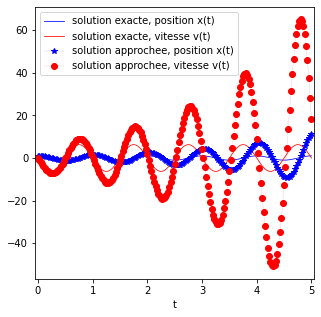

In [17]:
param = Param()

# Definition des paramètres
param.T = 5.
param.dt = 0.025
param.n = int(param.T / param.dt)

# appel de init_linear pour création de A et U0
init_linear(param)

# tableau des valeurs temporelles
tabtemps(param)

# Calcul de la solution exacte (mise à jour de l'attribut param.solution_exacte)
calcul_solution_exacte(param)

# calcul de la solution approchée (mise à jour de l'attribut param.solution_approchee)
euler_explicite(param)

# appel de oscillateur_fig1d
oscillateur_fig1d(param)

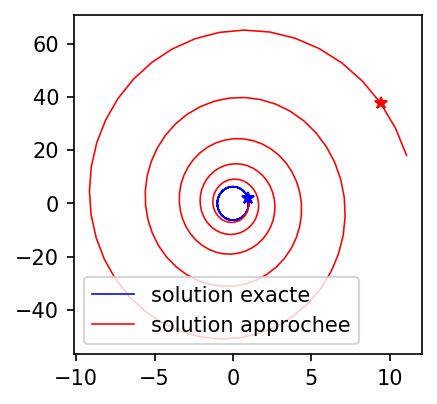

In [18]:
#======== Plan de phase animé =========
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150  
plt.ioff()
fig, ax = plt.subplots(figsize=(3,3))

animation.FuncAnimation(fig, animate, frames=range(0,param.n,int(param.n/30)))

**d)** Créez la matrice $P$, le propagateur du schéma d'Euler explicite pour ce problème, et calculez ses valeurs propres en utilisant la fonction `scipy.linalg.eigvals(P)`. Qu'en déduisez-vous ?

Rappel : $P = \begin {pmatrix}  1 & \Delta t  \cr -\omega^2 \Delta t & 1  \end {pmatrix}$

In [19]:
P = np.array([[1., param.dt],[- param.dt * param.omega**2, 1.]])
scipy.linalg.eigvals(P)

array([1.+0.15707963j, 1.-0.15707963j])

**4)** Reprendre **a), b), c)** de la question précédente avec **Euler implicite**. Que remarquez-vous ?

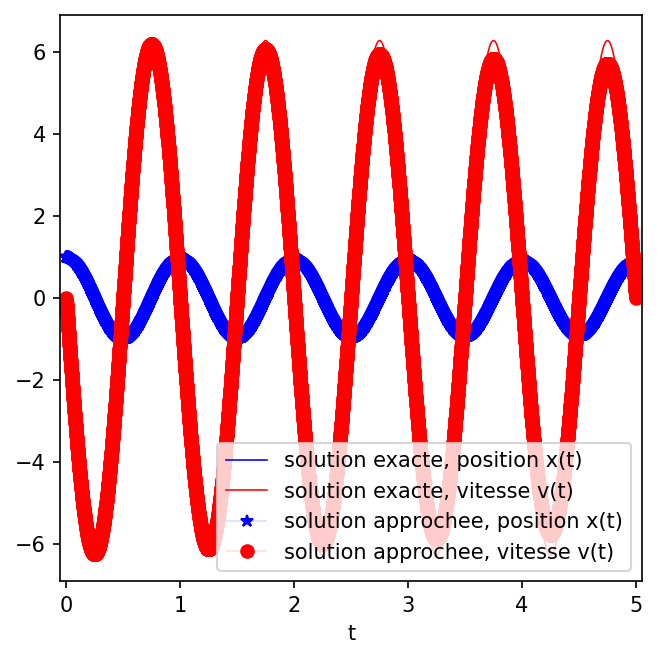

In [20]:
param = Param()

# Definition des paramètres
param.T = 5.
param.dt = 0.001
param.n = int(param.T / param.dt)

# appel de init_linear pour création de A et U0
init_linear(param)

# tableau des valeurs temporelles
tabtemps(param)

# Calcul de la solution exacte (mise à jour de l'attribut param.solution_exacte)
calcul_solution_exacte(param)

# calcul de la solution approchée (mise à jour de l'attribut param.solution_approchee)
euler_implicite(param)

# appel de oscillateur_fig1d
oscillateur_fig1d(param)

Avec le schéma d'Euler implicite on a :

$$
 \begin{array}{rcl} U^{n+1} &=& U^n + \Delta t (A U^{n+1}) \\
\Longleftrightarrow \ U^{n+1} &=&  \underbrace{(Id - \Delta t \ A)^{-1}}_{P} U^n \\
\Longleftrightarrow \ U^{n+1} &=&  P \ U^n
\end{array}
$$


Dans le cas du système masse-ressort, puisque $A =  \begin {pmatrix}  0 & 1  \cr -\omega^2  & 0  \end {pmatrix}$, alors $P = \begin {pmatrix}  1 & -\Delta t  \cr \omega^2 \Delta t & 1  \end {pmatrix}^{-1}$.   
Cette matrice $P$ est le *propagateur* pour la méthode d'Euler implicite appliquée à l'oscillateur harmonique du système masse-ressort.

In [21]:
param.dt = 0.0001
P = np.array([[1., -param.dt],[param.dt * param.omega**2, 1.]])
P = np.linalg.inv(P)
print('Propagateur P = \n', P)
eig = scipy.linalg.eigvals(P)
mod1 = np.sqrt(eig[0].real**2 + eig[0].imag**2)
mod2 = np.sqrt(eig[1].real**2 + eig[1].imag**2)
print('Valeurs propres de P = \n', eig)
print('Module des valeurs propres de P = \n', mod1, mod2)

Propagateur P = 
 [[ 9.99999605e-01  9.99999605e-05]
 [-3.94784020e-03  9.99999605e-01]]
Valeurs propres de P = 
 [0.99999961+0.00062832j 0.99999961-0.00062832j]
Module des valeurs propres de P = 
 0.9999998026079705 0.9999998026079705


On voit que le propagateur $P$ associé au schéma d'Euler implicite a des valeurs propres dont le module reste inférieur à 1, quelle que soit la valeur du pas de temps $\Delta t$. En réalité, quand $\Delta t$ tend vers 0, les valeurs propres de $P$ convergent en module vers 1 **par valeurs inférieures**. Ainsi, le schéma reste stable et la solution sera toujours bornée (= elle n'"explosera" pas).

La solution approchée avec Euler implicite sera d'autant plus précise (i.e. proche de la solution exacte) que le pas de temps $\Delta t$ sera petit.

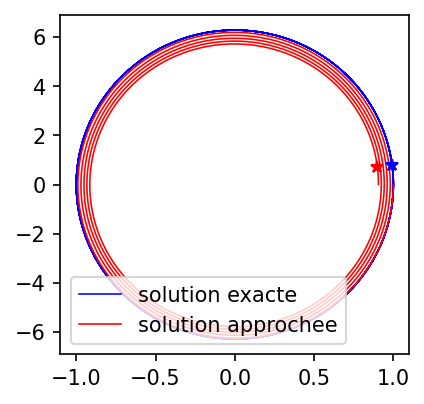

In [22]:
#======== Plan de phase animé =========
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150  
plt.ioff()
fig, ax = plt.subplots(figsize=(3,3))

animation.FuncAnimation(fig, animate, frames=range(0,param.n,int(param.n/30)))

**5)** Reprendre **a), b), c)** de la question précédente avec **Crank-Nicolson**. Que remarquez-vous ?

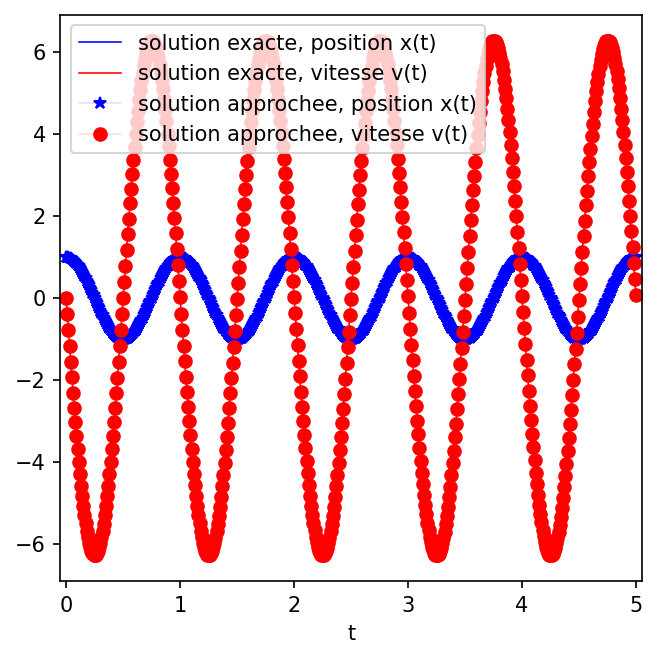

In [23]:
param = Param()
# Definition des paramètres
param.T = 5.
param.dt = 0.01
param.n = int(param.T / param.dt)

# appel de init_linear pour création de A et U0
init_linear(param)

# tableau des valeurs temporelles
tabtemps(param)

# Calcul de la solution exacte (mise à jour de l'attribut param.solution_exacte)
calcul_solution_exacte(param)

# calcul de la solution approchée (mise à jour de l'attribut param.solution_approchee)
crank_nicolson(param)

# appel de oscillateur_fig1d
oscillateur_fig1d(param)

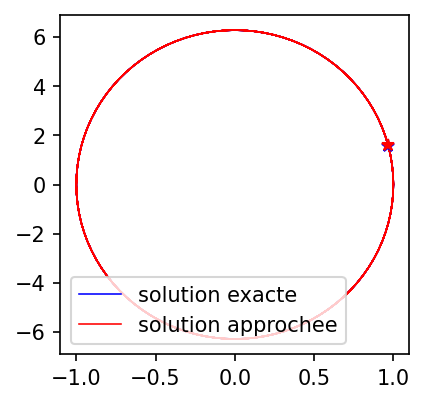

In [24]:
#======== Plan de phase animé =========
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150  
plt.ioff()
fig, ax = plt.subplots(figsize=(3,3))

animation.FuncAnimation(fig, animate, frames=range(0,param.n,int(param.n/30)))

**6)** Reprendre **a), b), c)** de la question précédente avec **Heun**. Que remarquez-vous ?

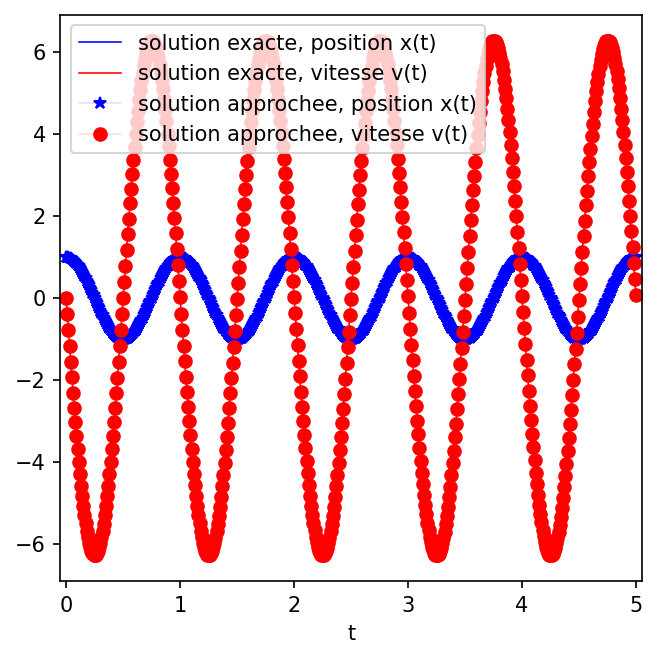

In [25]:
param = Param()
# Definition des paramètres
param.T = 5.
param.dt = 0.01
param.n = int(param.T / param.dt)

# appel de init_linear pour création de A et U0
init_linear(param)

# tableau des valeurs temporelles
tabtemps(param)

# Calcul de la solution exacte (mise à jour de l'attribut param.solution_exacte)
calcul_solution_exacte(param)

# calcul de la solution approchée (mise à jour de l'attribut param.solution_approchee)
crank_nicolson(param)

# appel de oscillateur_fig1d
oscillateur_fig1d(param)

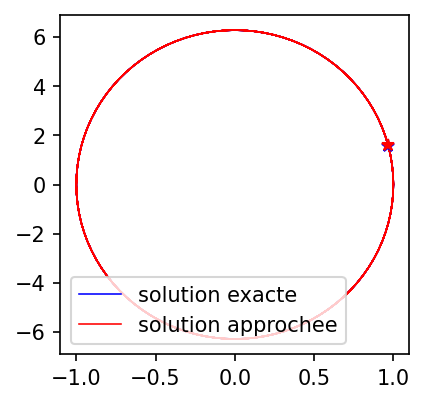

In [26]:
#======== Plan de phase animé =========
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150  
plt.ioff()
fig, ax = plt.subplots(figsize=(3,3))

animation.FuncAnimation(fig, animate, frames=range(0,param.n,int(param.n/30)))

**7)** En reprenant l'esprit de la dernière question sur le TP 3 de Crank-Nicolson et Heun, tracer les courbes de convergence pour les 4 méthodes (Euler explicite, Euler implicite, Crank-Nicolson et Heun) pour le problème de l'oscillateur harmonique étudié dans ce TP.  
Qu'observez-vous ?

*Remarque importante* : Dans le cas d'un problème d'ordre 2 ici, le calcul des erreurs se fera en utilisant la formule suivante :

$$ err = \vert x_{num}(n \Delta t) - x_{ex}(n \Delta t) \vert + \vert v_{num}(n \Delta t) - v_{ex}(n \Delta t) \vert $$

où $x$ et $v$ sont les deux composantes du vecteur $U$.

In [27]:
param = Param()
param.T = 1

init_linear(param)

N = 10 # nombre de simulations
errEE = np.zeros(N)
errEI = np.zeros(N)
errCN = np.zeros(N)
errH = np.zeros(N)
ite = np.zeros(N)
for i in range (0,N) :
    ite[i] = 2**(i+2)
    
    param.n = int(ite[i])
    n = param.n
    param.dt = param.T / param.n 
    
    tabtemps(param)
    calcul_solution_exacte(param)
    
    # Calcul des erreurs
    euler_explicite(param)
    errEE[i] = np.abs(param.solution_approchee[n, 0] - param.solution_exacte[n, 0])
    errEE[i] += np.abs(param.solution_approchee[n, 1] - param.solution_exacte[n, 1])  
    #
    euler_implicite(param)
    errEI[i] = np.abs(param.solution_approchee[n, 0] - param.solution_exacte[n, 0])
    errEI[i] += np.abs(param.solution_approchee[n, 1] - param.solution_exacte[n, 1])
    #
    crank_nicolson(param)
    errCN[i] = np.abs(param.solution_approchee[n, 0] - param.solution_exacte[n, 0])
    errCN[i] += np.abs(param.solution_approchee[n, 1] - param.solution_exacte[n, 1])
    #
    heun(param)
    errH[i] = np.abs(param.solution_approchee[n, 0] - param.solution_exacte[n, 0])
    errH[i] += np.abs(param.solution_approchee[n, 1] - param.solution_exacte[n, 1])

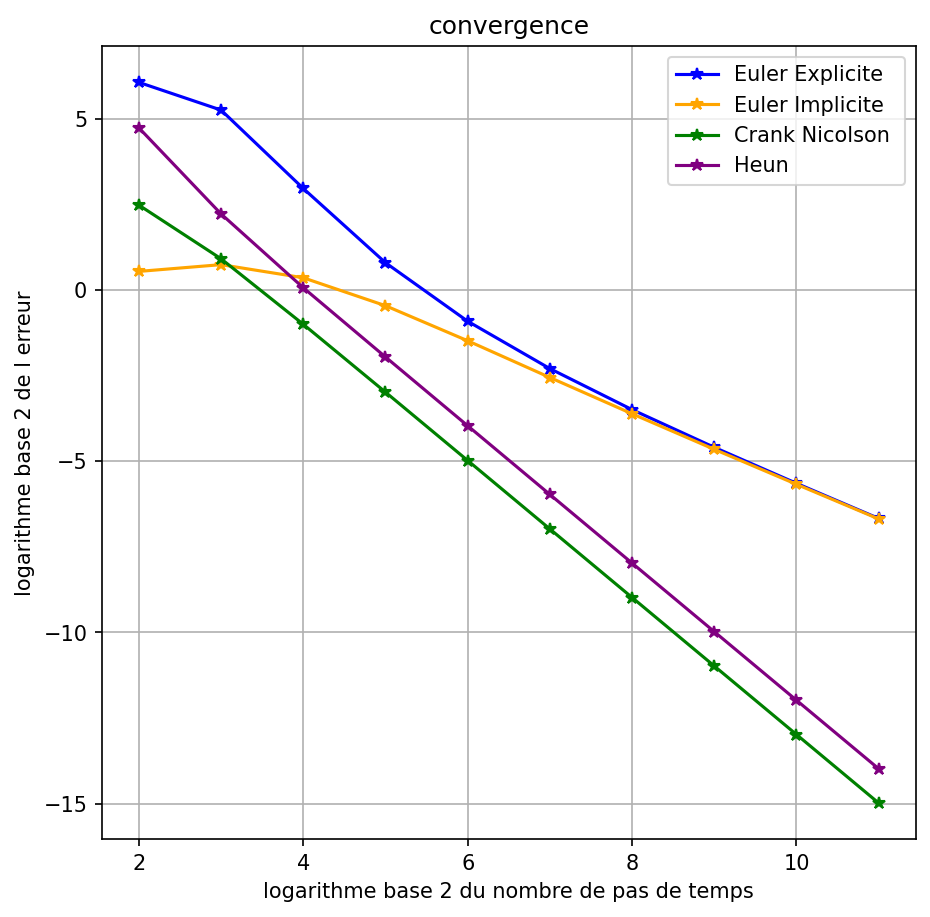

In [28]:
if (N >= 2) :
    PlotConv4c(ite, errEE, errEI, errCN, errH)